In [2]:
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import shap

c:\Users\Elena\OneDrive - Rutgers University\Documents\VS Code\1. SCNP Modeling 04_27_2026\.venv_kratky\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# load the data
data = pd.read_excel('../data/Featurized Polymer SAXS Data.xlsx')

# drop the rows that did not have GMM cluster assigned
data = data[data['GMM Cluster'].notnull()]

print(f"Total number of samples: {data['GMM Cluster'].notnull().sum()}") # should be 384
print(f"Total number of unique polymers: {data['Polymer_ID'].nunique()}") # should be 156

Total number of samples: 384
Total number of unique polymers: 156


In [7]:
# make target: kratky cluster
data['Kratky Class'] = data['GMM Cluster'].replace({0: 0, 3: 0, 4: 0, 1: 0, 2: 1})

# name the bins
data['Kratky Class Label'] = data['Kratky Class'].map({0: 'Ordered', 1: 'Disordered'})

print(data['Kratky Class Label'].value_counts())

# set initial features
potential_features = ['Concentration',  'Total Charge', 'Net Charge', 
                      'LogP', 'Molecular Weight (Da)', 'Surface Area (Å²)', 
                      'HBD', 'HBA', 'HBT', 'HBDiff', 'HBR', 'Neutral Fraction']

# Select features and target
features = potential_features
X = data[features].copy()
y = data['Kratky Class']
groups = data['Polymer_ID']

# Drop rows with NaNs in either X or y
valid_idx = X.index[X.notna().all(axis=1) & y.notna()]
X = X.loc[valid_idx]
y = y.loc[valid_idx]
groups = groups.loc[valid_idx]

print(f"Number of unique polymers in usable samples: {data.loc[X.index, 'Polymer_ID'].nunique()}")
print(f"Number of groups in usable samples: {groups.nunique()}")

Kratky Class Label
Disordered    284
Ordered       100
Name: count, dtype: int64
Number of unique polymers in usable samples: 156
Number of groups in usable samples: 156


In [ ]:
# prep for data splitting

gkf = GroupKFold(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
    print(f"Fold {fold}: Train groups = {groups.iloc[train_idx].nunique()}, Test groups = {groups.iloc[test_idx].nunique()}")

Fold 1: Train groups = 125, Test groups = 31
Fold 2: Train groups = 125, Test groups = 31
Fold 3: Train groups = 124, Test groups = 32
Fold 4: Train groups = 125, Test groups = 31
Fold 5: Train groups = 125, Test groups = 31


In [ ]:
# trying a few classifiers to see which works best

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "SVM": SVC(probability=True)
}

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
    print(f"\nFold {fold}")
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Feature selection on training set
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    rfe = RFE(clf, n_features_to_select=5)
    rfe.fit(X_train, y_train)
    selected_features = X_train.columns[rfe.support_].tolist()
    print("Selected features:", selected_features)

    # Scale features for models that require it
    scaler = StandardScaler()
    X_train_scaled = X_train[selected_features].copy()
    X_test_scaled = X_test[selected_features].copy()
    # Only scale for models that benefit: Logistic Regression, SVM, XGBoost (optional)
    X_train_scaled = scaler.fit_transform(X_train[selected_features])
    X_test_scaled = scaler.transform(X_test[selected_features])

    for name, model in models.items():
        if name in ["Logistic Regression", "SVM", "XGBoost"]:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            # Random Forest does not require scaling
            model.fit(X_train[selected_features], y_train)
            y_pred = model.predict(X_test[selected_features])
        print(f"\n{name}")
        print(classification_report(y_test, y_pred))
        print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")


Fold 1
Selected features: ['LogP', 'Molecular Weight (Da)', 'HBT', 'HBR', 'Neutral Fraction']

Logistic Regression
              precision    recall  f1-score   support

         0.0       0.75      1.00      0.86        15
         1.0       1.00      0.92      0.96        62

    accuracy                           0.94        77
   macro avg       0.88      0.96      0.91        77
weighted avg       0.95      0.94      0.94        77

Balanced accuracy: 0.960

Random Forest
              precision    recall  f1-score   support

         0.0       0.62      1.00      0.77        15
         1.0       1.00      0.85      0.92        62

    accuracy                           0.88        77
   macro avg       0.81      0.93      0.85        77
weighted avg       0.93      0.88      0.89        77

Balanced accuracy: 0.927


c:\Users\Elena\OneDrive - Rutgers University\Documents\VS Code\1. SCNP Modeling 04_27_2026\.venv_kratky\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:09:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
              precision    recall  f1-score   support

         0.0       0.64      0.93      0.76        15
         1.0       0.98      0.87      0.92        62

    accuracy                           0.88        77
   macro avg       0.81      0.90      0.84        77
weighted avg       0.91      0.88      0.89        77

Balanced accuracy: 0.902

SVM
              precision    recall  f1-score   support

         0.0       0.75      1.00      0.86        15
         1.0       1.00      0.92      0.96        62

    accuracy                           0.94        77
   macro avg       0.88      0.96      0.91        77
weighted avg       0.95      0.94      0.94        77

Balanced accuracy: 0.960

Fold 2
Selected features: ['LogP', 'HBA', 'HBT', 'HBR', 'Neutral Fraction']

Logistic Regression
              precision    recall  f1-score   support

         0.0       0.62      0.36      0.46        22
         1.0       0.78      0.91      0.84        55

    accuracy        

c:\Users\Elena\OneDrive - Rutgers University\Documents\VS Code\1. SCNP Modeling 04_27_2026\.venv_kratky\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:09:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Selected features: ['LogP', 'HBA', 'HBT', 'HBR', 'Neutral Fraction']

Logistic Regression
              precision    recall  f1-score   support

         0.0       0.78      0.58      0.67        24
         1.0       0.83      0.92      0.88        53

    accuracy                           0.82        77
   macro avg       0.80      0.75      0.77        77
weighted avg       0.81      0.82      0.81        77

Balanced accuracy: 0.754

Random Forest
              precision    recall  f1-score   support

         0.0       0.91      0.88      0.89        24
         1.0       0.94      0.96      0.95        53

    accuracy                           0.94        77
   macro avg       0.93      0.92      0.92        77
weighted avg       0.93      0.94      0.93        77

Balanced accuracy: 0.919

XGBoost
              precision    recall  f1-score   support

         0.0       0.90      0.75      0.82        24
         1.0       0.89      0.96      0.93        53

    accuracy      

c:\Users\Elena\OneDrive - Rutgers University\Documents\VS Code\1. SCNP Modeling 04_27_2026\.venv_kratky\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:09:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Selected features: ['LogP', 'Molecular Weight (Da)', 'HBA', 'HBT', 'Neutral Fraction']

Logistic Regression
              precision    recall  f1-score   support

         0.0       0.62      0.62      0.62        16
         1.0       0.90      0.90      0.90        60

    accuracy                           0.84        76
   macro avg       0.76      0.76      0.76        76
weighted avg       0.84      0.84      0.84        76

Balanced accuracy: 0.762

Random Forest
              precision    recall  f1-score   support

         0.0       0.69      0.69      0.69        16
         1.0       0.92      0.92      0.92        60

    accuracy                           0.87        76
   macro avg       0.80      0.80      0.80        76
weighted avg       0.87      0.87      0.87        76

Balanced accuracy: 0.802

XGBoost
              precision    recall  f1-score   support

         0.0       0.75      0.56      0.64        16
         1.0       0.89      0.95      0.92        60



c:\Users\Elena\OneDrive - Rutgers University\Documents\VS Code\1. SCNP Modeling 04_27_2026\.venv_kratky\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:09:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Selected features: ['LogP', 'Molecular Weight (Da)', 'HBA', 'HBT', 'Neutral Fraction']

Logistic Regression
              precision    recall  f1-score   support

         0.0       0.92      0.48      0.63        23
         1.0       0.81      0.98      0.89        53

    accuracy                           0.83        76
   macro avg       0.86      0.73      0.76        76
weighted avg       0.84      0.83      0.81        76

Balanced accuracy: 0.730

Random Forest
              precision    recall  f1-score   support

         0.0       0.75      0.52      0.62        23
         1.0       0.82      0.92      0.87        53

    accuracy                           0.80        76
   macro avg       0.78      0.72      0.74        76
weighted avg       0.80      0.80      0.79        76

Balanced accuracy: 0.723

XGBoost
              precision    recall  f1-score   support

         0.0       0.58      0.61      0.60        23
         1.0       0.83      0.81      0.82        53



c:\Users\Elena\OneDrive - Rutgers University\Documents\VS Code\1. SCNP Modeling 04_27_2026\.venv_kratky\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:09:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# tabular results of balanced accuracy for each model and fold, with average at the end so i can compare it easier
import numpy as np
from sklearn.preprocessing import StandardScaler
results = []
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Scale all features first for SVM-based RFE
    scaler_rfe = StandardScaler()
    X_train_scaled_all = scaler_rfe.fit_transform(X_train)
    X_test_scaled_all = scaler_rfe.transform(X_test)

    # Feature selection using SVM-RFE on scaled data
    svm_for_rfe = SVC(kernel='linear', random_state=42)  # Linear kernel works best for RFE
    rfe = RFE(svm_for_rfe, n_features_to_select=4)
    rfe.fit(X_train_scaled_all, y_train)
    selected_features = X_train.columns[rfe.support_].tolist()

    # Scale only selected features for final models
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train[selected_features])
    X_test_scaled = scaler.transform(X_test[selected_features])

    for name, model in models.items():
        if name in ["Logistic Regression", "SVM", "XGBoost"]:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            # Random Forest does not require scaling
            model.fit(X_train[selected_features], y_train)
            y_pred = model.predict(X_test[selected_features])
        bal_acc = balanced_accuracy_score(y_test, y_pred)
        results.append({
            'Fold': fold,
            'Model': name,
            'Balanced Accuracy': bal_acc
        })
results_df = pd.DataFrame(results)
pivot_df = results_df.pivot(index='Fold', columns='Model', values='Balanced Accuracy')
print(pivot_df)
print("\nAverage Balanced Accuracy:")
print(pivot_df.mean())

c:\Users\Elena\OneDrive - Rutgers University\Documents\VS Code\1. SCNP Modeling 04_27_2026\.venv_kratky\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:10:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Elena\OneDrive - Rutgers University\Documents\VS Code\1. SCNP Modeling 04_27_2026\.venv_kratky\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:10:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Elena\OneDrive - Rutgers University\Documents\VS Code\1. SCNP Modeling 04_27_2026\.venv_kratky\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:10:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo

Model  Logistic Regression  Random Forest       SVM   XGBoost
Fold                                                         
1                 0.959677       0.868817  0.959677  0.876882
2                 0.718182       0.700000  0.668182  0.627273
3                 0.753931       0.823899  0.795597  0.786164
4                 0.793750       0.683333  0.825000  0.708333
5                 0.794914       0.694832  0.723134  0.666530

Average Balanced Accuracy:
Model
Logistic Regression    0.804091
Random Forest          0.754176
SVM                    0.794318
XGBoost                0.733036
dtype: float64


c:\Users\Elena\OneDrive - Rutgers University\Documents\VS Code\1. SCNP Modeling 04_27_2026\.venv_kratky\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:10:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Running 5-fold cross-validation with concatenated predictions...
Fold 1: Balanced Accuracy = 0.911, Test Samples = 77
Fold 2: Balanced Accuracy = 0.668, Test Samples = 77
Fold 3: Balanced Accuracy = 0.851, Test Samples = 77
Fold 4: Balanced Accuracy = 0.825, Test Samples = 76
Fold 5: Balanced Accuracy = 0.841, Test Samples = 76
OVERALL RESULTS (All 5 Folds Combined):
Total samples: 383
Overall Balanced Accuracy: 0.813 ± 0.081

Overall Classification Report:
              precision    recall  f1-score   support

     Ordered       0.65      0.77      0.71       100
  Disordered       0.91      0.86      0.88       283

    accuracy                           0.83       383
   macro avg       0.78      0.81      0.79       383
weighted avg       0.85      0.83      0.84       383



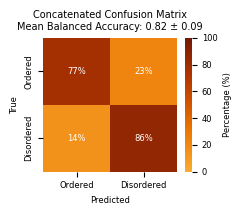


Individual Fold Results:
   Fold  Balanced_Accuracy  Test_Samples  Balanced_Accuracy_Rounded
0     1           0.911290            77                      0.911
1     2           0.668182            77                      0.668
2     3           0.850629            77                      0.851
3     4           0.825000            76                      0.825
4     5           0.841263            76                      0.841

Mean Balanced Accuracy across folds: 0.82 ± 0.09

Confusion Matrix (Counts):
                 Predicted
True    Ordered  Disordered
Ordered     77       23
Disordered  41      242

Confusion Matrix (Percentages):
                 Predicted
True    Ordered  Disordered
Ordered    77.0%     23.0%
Disordered  14.5%     85.5%


In [ ]:
# Concatenated confusion matrix across all 5 folds and classification report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Set the features and model
selected_features = ['LogP', 'Molecular Weight (Da)', 'HBT', 'Neutral Fraction']

# Initialize lists to collect all predictions and true values
all_y_true = []
all_y_pred = []
fold_results = []

print("Running 5-fold cross-validation with concatenated predictions...")
print("=" * 60)

# Run through all 5 folds
gkf = GroupKFold(n_splits=5)
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
    # Create model for this fold
    model = LogisticRegression(class_weight='balanced', max_iter=1000)
    
    # Split data for this fold
    X_train_fold = X.iloc[train_idx][selected_features]
    X_test_fold = X.iloc[test_idx][selected_features]
    y_train_fold = y.iloc[train_idx]
    y_test_fold = y.iloc[test_idx]
    
    # Fit and predict
    model.fit(X_train_fold, y_train_fold)
    y_pred_fold = model.predict(X_test_fold)
    
    # Calculate balanced accuracy for this fold
    fold_balanced_acc = balanced_accuracy_score(y_test_fold, y_pred_fold)
    
    # Store results
    fold_results.append({
        'Fold': fold,
        'Balanced_Accuracy': fold_balanced_acc,
        'Test_Samples': len(y_test_fold)
    })
    
    # Add to concatenated lists
    all_y_true.extend(y_test_fold.tolist())
    all_y_pred.extend(y_pred_fold.tolist())
    
    print(f"Fold {fold}: Balanced Accuracy = {fold_balanced_acc:.3f}, Test Samples = {len(y_test_fold)}")

print("=" * 60)

# Convert to numpy arrays for easier manipulation
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

# Calculate overall metrics
overall_balanced_acc = balanced_accuracy_score(all_y_true, all_y_pred)
overall_balanced_std = np.std([result['Balanced_Accuracy'] for result in fold_results])
overall_cm = confusion_matrix(all_y_true, all_y_pred)

print(f"OVERALL RESULTS (All 5 Folds Combined):")
print(f"Total samples: {len(all_y_true)}")
print(f"Overall Balanced Accuracy: {overall_balanced_acc:.3f} ± {overall_balanced_std:.3f}")

print(f"\nOverall Classification Report:")
print(classification_report(all_y_true, all_y_pred, target_names=['Ordered', 'Disordered']))

# Create the concatenated confusion matrix visualization
colors = ['#EFEDFF', '#231f5a']
sunset = ['#9EBCF5', '#2D5FAC', '#F9AC2F','#EA7100', '#BA3B00', '#741905', '#BA9BD4', '#75439D', '#330956' ]
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", sunset[2:6])

# Calculate percentage confusion matrix (normalize by true class)
cm_percent = overall_cm.astype('float') / overall_cm.sum(axis=1)[:, np.newaxis] * 100

# Create custom annotations with % signs
annot_labels = np.array([[f'{val:.0f}%' for val in row] for row in cm_percent])

shape_confusion = plt.figure(figsize=(2.5, 2.25))
ax = sns.heatmap(cm_percent, annot_kws={'fontsize': 6}, annot=annot_labels, fmt='', cmap=custom_cmap,
            xticklabels=['Ordered', 'Disordered'], 
            yticklabels=['Ordered', 'Disordered'],
            cbar_kws={'label': 'Percentage (%)'}, vmin=0, vmax=100)
ax.tick_params(axis='both', which='major', labelsize=6)

# 4. Set fontsize for Colorbar Label and Ticks
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=6) # Ticks (0, 20, ..., 100)
cbar.set_label('Percentage (%)', fontsize=6) # Label ('Percentage (%)')


fold_df = pd.DataFrame(fold_results)
mean_acc = fold_df['Balanced_Accuracy'].mean()
std_acc = fold_df['Balanced_Accuracy'].std()
plt.xlabel('Predicted', fontsize=6)
plt.ylabel('True', fontsize=6)
plt.title(f'Concatenated Confusion Matrix\nMean Balanced Accuracy: {mean_acc:.2f} ± {std_acc:.2f}', fontsize=7)
plt.tight_layout()
plt.show()

# save the figure in high res
shape_confusion.savefig('../imgs/shape classification/shape classifier confusion matrix.svg', dpi=600, bbox_inches='tight', transparent=True)

# Show individual fold results
import pandas as pd

fold_df['Balanced_Accuracy_Rounded'] = fold_df['Balanced_Accuracy'].round(3)
print(f"\nIndividual Fold Results:")
print(fold_df)
print(f"\nMean Balanced Accuracy across folds: {fold_df['Balanced_Accuracy'].mean():.2f} ± {fold_df['Balanced_Accuracy'].std():.2f}")

print(f"\nConfusion Matrix (Counts):")
print(f"                 Predicted")
print(f"True    Ordered  Disordered")
print(f"Ordered    {overall_cm[0,0]:3d}      {overall_cm[0,1]:3d}")
print(f"Disordered {overall_cm[1,0]:3d}      {overall_cm[1,1]:3d}")

print(f"\nConfusion Matrix (Percentages):")
print(f"                 Predicted")
print(f"True    Ordered  Disordered")
print(f"Ordered   {cm_percent[0,0]:5.1f}%    {cm_percent[0,1]:5.1f}%")
print(f"Disordered {cm_percent[1,0]:5.1f}%    {cm_percent[1,1]:5.1f}%")

Creating SHAP summary plot for concatenated cross-validation results...
Computing SHAP values for Fold 1...
Computing SHAP values for Fold 2...
Computing SHAP values for Fold 3...
Computing SHAP values for Fold 4...
Computing SHAP values for Fold 5...
Total test samples across all folds: 383
SHAP values shape: (383, 4)
Features: ['LogP', 'Molecular Weight (Da)', 'HBT', 'Neutral Fraction']


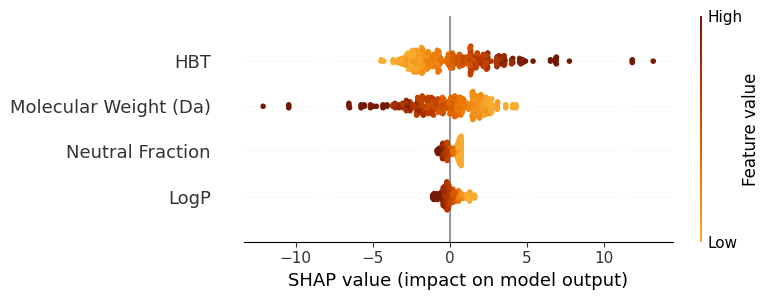

SHAP analysis complete!
The plot shows feature importance and impact across all 383 test samples
from the 5-fold cross-validation.


In [18]:
# SHAP summary plot for concatenated 5-fold cross-validation results

print("Creating SHAP summary plot for concatenated cross-validation results...")
print("=" * 60)

# Collect all test data and SHAP values across all folds
all_X_test = []
all_shap_values = []

# Re-run through folds to collect SHAP data
gkf = GroupKFold(n_splits=5)
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
    print(f"Computing SHAP values for Fold {fold}...")
    
    # Create model for this fold
    model = LogisticRegression(class_weight='balanced', max_iter=1000)
    
    # Split data for this fold
    X_train_fold = X.iloc[train_idx][selected_features]
    X_test_fold = X.iloc[test_idx][selected_features]
    y_train_fold = y.iloc[train_idx]
    
    # Fit model
    model.fit(X_train_fold, y_train_fold)
    
    # Create SHAP explainer and calculate SHAP values
    explainer = shap.Explainer(model, X_train_fold)
    shap_values_fold = explainer(X_test_fold)
    
    # Store the test data and SHAP values
    all_X_test.append(X_test_fold)
    all_shap_values.append(shap_values_fold.values)

# Concatenate all test data and SHAP values
X_test_concatenated = pd.concat(all_X_test, axis=0)
shap_values_concatenated = np.concatenate(all_shap_values, axis=0)

print(f"Total test samples across all folds: {len(X_test_concatenated)}")
print(f"SHAP values shape: {shap_values_concatenated.shape}")
print(f"Features: {list(X_test_concatenated.columns)}")

# Create the SHAP summary plot with custom colors
sunset = ['#9EBCF5', '#2D5FAC', '#F9AC2F','#EA7100', '#BA3B00', '#741905', '#BA9BD4', '#75439D', '#330956' ]
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", sunset[2:6])

shape = plt.figure(figsize=(3, 2))
shap.summary_plot(shap_values_concatenated, X_test_concatenated, 
                  cmap=custom_cmap, 
                  feature_names=X_test_concatenated.columns,
                  show=False)
#plt.title('SHAP Summary Plot - Concatenated 5-Fold Cross-Validation\n(All Test Predictions Combined)', 
          #fontsize=6, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# save the kratky plot in high resolution (300 dpi) with a transparent background in the img folder
shape.savefig('../imgs/shape classification/shape classifier shap summary.svg', dpi=600, bbox_inches='tight', transparent=True)

print("=" * 60)
print("SHAP analysis complete!")
print(f"The plot shows feature importance and impact across all {len(X_test_concatenated)} test samples")
print("from the 5-fold cross-validation.")